# Solar Module Waste Projection

### Independent Research Notebook #2 — Solar Panel Recycling

This notebook presents a visual analysis of projected end-of-life (EOL) waste from currently installed solar PV modules. The figure below illustrates PV waste generation forecasts up to 2051, based on open-source data from Our World in Data (IRENA, 2025). Several assumptions were applied in the analysis to support these projections; these assumptions and their implications are discussed in the accompanying markdown cells. This notebook is the second part of my independent research project on solar panel recycling, aiming to highlight the potential environmental impacts of PV waste and encourage strategies for sustainable recycling and materials recovery.


Cumulative PV waste by 2051: 86.47 million tonnes


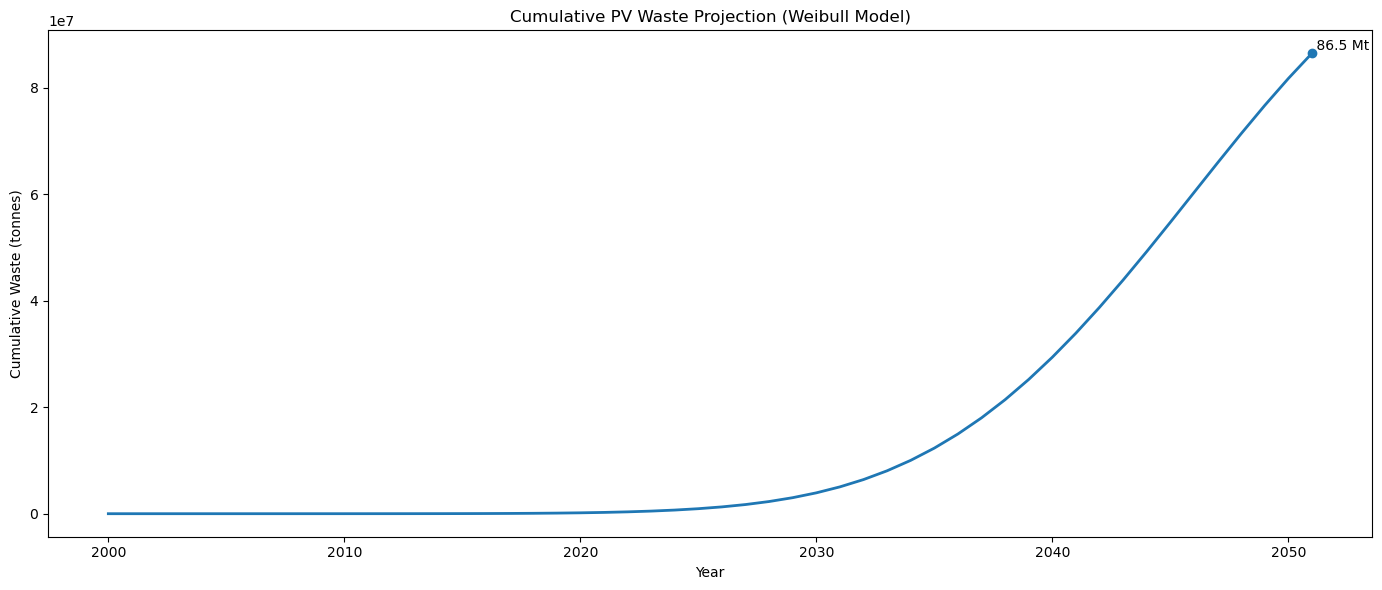

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.chdir(r"C:\Users\kelly\OneDrive\Desktop\solar-panel-recycling-analysis-main")
os.makedirs("results/figures", exist_ok=True)

TONNES_PER_MW = 60
END_YEAR = 2051

eta = 27
beta = 4

def weibull_failure_fraction(age):
    F_t = 1 - np.exp(-(age/eta)**beta)
    F_t_minus = 1 - np.exp(-((age-1)/eta)**beta) if age > 0 else 0
    return F_t - F_t_minus

ages = np.arange(1, 61)
failure_fraction = {age: weibull_failure_fraction(age) for age in ages}

df = pd.read_csv("data/global_installations.csv")
df = df.rename(columns={"Solar capacity (GW)": "capacity_GW"})
df = df.sort_values("Year")
df = df[df["Entity"] == "World"]
df["annual_GW"] = df["capacity_GW"].diff()
df["annual_GW"] = df["annual_GW"].fillna(df["capacity_GW"])
df["annual_GW"] = df["annual_GW"].clip(lower=0)
df["annual_MW"] = df["annual_GW"] * 1000
df["installed_mass_tonnes"] = df["annual_MW"] * TONNES_PER_MW

waste = {}

for _, row in df.iterrows():

    install_year = row["Year"]
    installed_mass = row["installed_mass_tonnes"]

    for age in ages:

        fail_year = install_year + age

        if fail_year > END_YEAR:
            continue

        frac = failure_fraction[age]

        waste.setdefault(fail_year, 0)
        waste[fail_year] += installed_mass * frac

waste_df = pd.Series(waste).sort_index()
years = pd.DataFrame({"Year": range(df["Year"].min(), END_YEAR + 1)})

df = pd.merge(years, df, on="Year", how="left")
df["pv_waste_tonnes"] = df["Year"].map(waste_df).fillna(0)
df["cumulative_waste_tonnes"] = df["pv_waste_tonnes"].cumsum()

cum_2051 = df.loc[df["Year"] == 2051, "cumulative_waste_tonnes"].values[0]
print(f"Cumulative PV waste by 2051: {cum_2051/1e6:.2f} million tonnes")

plt.figure(figsize=(14,6))
plt.plot(df["Year"], df["cumulative_waste_tonnes"], linewidth=2)
plt.scatter(2051, cum_2051)
plt.text(
    2051,
    cum_2051,
    f" {cum_2051/1e6:.1f} Mt",
    verticalalignment="bottom"
)

plt.xlabel("Year")
plt.ylabel("Cumulative Waste (tonnes)")
plt.title("Cumulative PV Waste Projection (Weibull Model)")

plt.tight_layout()
plt.savefig("results/figures/cumulative_pv_waste_projection_weibull.png", dpi=300, bbox_inches="tight")
plt.show()

## Markdown

### 1. Waste Generation Figure Analysis

This notebook estimates cumulative global photovoltaic (PV) waste generation using historical deployment data. The methodology is based on assumptions found in published literature and cited below. 

This waste projection model highlights the urgency with which governments and industry must implement effective recycling policies and technologies for solar photovoltaic systems. Delaying proper action until 2050 risks overlooking the scale and immediacy of this challenge. Early-generation PV modules often contain hazardous materials which, if not properly managed at end-of-life, can pose significant environmental risks. In particular, landfilling of solar panels represents one of the most environmentally damaging disposal pathways (Bošnjaković et al., 2023).

Overall, these findings emphasise the need for proactive intervention and should serve as a clear **call to action** for policymakers, researchers, and the global community.

---

## 2. Data Source

- Historical solar PV capacity data are obtained from datasets provided by Our World in Data (OWID) [^2].
- The analysis uses global (“World”) cumulative installed capacity reported in gigawatts (GW).

---

## 3. Converting Capacity to Module Mass

Installed PV capacity is converted to module mass using a constant material intensity assumption of **60 tonnes per MW of installed capacity**. 

Previous PV waste studies have commonly used **60 kg kW⁻¹ (equivalent to 60 t MW⁻¹)** as a representative value for crystalline silicon PV modules. For example, a study published in the journal *Sustainability* assumed a module mass intensity of 60 kg kW⁻¹ when estimating future photovoltaic waste generation based on historical and current installation data [^1]. 

Since 1 GW = 1000 MW, the mass of PV modules installed each year is calculated as:

Mass_t = (Installations_t [GW])(1000 [MW])(60 [t MW⁻¹])

where:

- Mass_t is the total mass of PV modules installed in year [t] [tonnes].

---

## 4. PV Module Lifetime and Failure Behaviour (Weibull Distribution)

PV module failures are modelled using a **Weibull distribution**, which is widely used in reliability engineering. The shape parameter chosen for this model, [β], is 4 to reflect slower degradation earlier on and an increasing failure probability after 10-20 years due to wear-out failure [^3][^4]. The scale parameter [η] chosen for this model is 27 years, which is the average design life of a solar PV module [^1]. 

Weibull Cumulative Distribution Function:

F(t) = 1 - e^{-(t/η)^\β}

- Parameters used:
  - Scale parameter (η): 27 years  
  - Shape parameter (β) = 4

  - This reflects failure over time rather than a fixed lifetime.

The model is then simulated in three steps:

1. Convert the Weibull Cumulative Distribution function above into discrete annual failure fractions 𝑝(𝑡). This represents the probability that a panel fails during year 𝑡:

𝑝(𝑡) = 𝐹(𝑡) − 𝐹(𝑡−1)

2. Apply these fractions to each installation cohort as it ages. Each installation year forms a cohort with mass 𝑀(𝑡). As the cohort ages, its failures are distributed across future years according to the Weibull fractions:

waste(𝑡→𝑦) = 𝑀(𝑡)𝑝(𝑦−𝑡)

3. Sum failures across all cohorts to obtain annual and cumulative waste in the form of a nested loop:

𝑊(𝑦)=∑𝑀(𝑡) 𝑝(𝑦−𝑡)

---

## 5. Waste Generation

- Modules are assumed to enter the waste stream upon failure.
- Waste beyond the model horizon (after 2051) is not included.

---

## 6. Time Horizon

- The model runs from the earliest available year in the dataset to **2051**.
- Future projections are included only up to this year.

---

## 7. Cumulative Waste Calculation

Cumulative PV waste is calculated in step 4.3 above. This metric is directly comparable to values reported in the literature, such as global PV waste projections of **86 million tonnes by 2050** [^1].

## 8. Key Simplifications

The model includes several simplifying assumptions:

- A **constant mass-to-capacity ratio** over time  
- No separation between PV technologies (e.g., crystalline silicon vs thin-film)  
- No regional variation in deployment or system characteristics  
- No modelling of reuse, refurbishment, or second-life applications  
- No explicit recycling or material recovery processes  
- No policy, economic, or supply chain constraints

---

## 9. Limitations

This modelling approach has several limitations:

### 9.1 Future Deployment Uncertainty
- This model does not project early failures of future installed solar PV modules

### 9.2 Material Intensity Assumption
- The use of a constant value (60 t/MW) does not account for:
  - improvements in module efficiency  
  - changes in module design or materials  

### 9.3 Lifetime Modelling
- Although the Weibull distribution improves realism, it is still a simplification.
- Real-world failures depend on factors such as:
  - environmental conditions (including climate change impacts) 
  - installation quality  
  - maintenance practices  

### 9.4 Data Limitations
- OWID data are aggregated globally and may mask regional variability.
- Historical data uncertainty propagates into future projections.

### 9.5 System Boundary
- The model assumes all failed modules become waste.
- It does not account for:
  - reuse or resale markets  
  - delayed disposal  
  - informal recycling pathways

---

## 10. Uncertainty

Uncertainty in the model arises from three main sources:

### 10.1 Scenario Uncertainty
- Future solar deployment trajectories are uncertain.
- Different energy scenarios could significantly alter results.

### 10.2 Parameter Uncertainty
- Key parameters are assumed rather than directly observed.
- Small changes in these values can produce large differences in long-term waste estimates.

### 10.3 Structural Uncertainty
- The choice of modelling approach influences results.
- Alternative modelling frameworks may yield different outcomes.

---

## 11. Interpretation

- Results should be interpreted as **scenario-based estimates**, not precise forecasts.
- The model provides an **order-of-magnitude understanding** of future PV waste generation.
- Outputs are most comparable to cumulative waste projections reported.

---

## 12. References

[^1] Bošnjaković, M., Galović, M., Kuprešak, J. and Bošnjaković, T. (2023) ‘The end of life of PV systems: Is Europe ready for it?’, Sustainability, 15(23), 16466. Available at: https://doi.org/10.3390/su152316466  (Accessed: [21 March 2026]).

[^2] IRENA (2025) – processed by Our World in Data. “Total solar capacity” [dataset]. IRENA, “Renewable Energy Statistics” [original data]. Retrieved March 11, 2026 from https://archive.ourworldindata.org/20260304-094028/grapher/installed-solar-pv-capacity.html (archived on March 4, 2026).

[^3] Kim, H. and Park, H., 2018. PV waste management at the crossroads of circular economy and energy transition: The case of South Korea. Sustainability, 10(10), p.3565. https://doi.org/10.3390/su10103565 (Accessed: [21 March 2026]).

[^4] Abernethy, R.B. (2002) The New Weibull Handbook: Chapter 1 – An Overview of Weibull Analysis. North Palm Beach, FL: Robert B. Abernethy. Available at: https://web.mit.edu/2.70/Reading%20Materials/Weibull%20handbook%20%20Chpt1.pdf  (Accessed: [21 March 2026]).